In [3]:
library(Seurat)
library(tidyverse)
library(data.table)
library(glue)
library(dplyr)

In [4]:
## 绘图函数写入独立文件，避免 notebook 超长；修改函数请编辑同名 .R 文件
source("/home/data/tanglei/project/cosmx/function/plotCosMxGenesWithCelltype.R")


In [6]:
metadata = data.table::fread("/home/data/tanglei/project/cosmx/CQT2025111030-F002-矩阵文件-flatFiles/SMI2026001/SMI2026001_metadata_file.backup_before_fix.csv", data.table = F)

In [7]:
tx = fread("/home/data/tanglei/project/cosmx/CQT2025111030-F002-矩阵文件-flatFiles/SMI2026001/SMI2026001_tx_file.csv", data.table = F)
tx = subset(tx, cell_ID != 0)

In [8]:
polygons = fread("/home/data/tanglei/project/cosmx/CQT2025111030-F002-矩阵文件-flatFiles/SMI2026001/SMI2026001-polygons.csv", data.table = F)

In [9]:
seu = qs::qread("/home/data/tanglei/project/cosmx/data/filter_fin.qs")
seu_list = qs::qread("/home/data/tanglei/project/cosmx/data/Split_list_fin.qs")

nerve-associated fibroblast spatial evidence

In [10]:
## 选择样本和视野
sample = "2444251"
spatial_1 = c(0, 12000)
spatial_2 = c(6200, 10000)

reduction = seu_list[[sample]]@reductions$spatial@cell.embeddings
s1_col = reduction[, "spatial_1", drop = TRUE]
s2_col = reduction[, "spatial_2", drop = TRUE]
keep = spatial_1[1] < s1_col & s1_col < spatial_1[2] &
       spatial_2[1] < s2_col & s2_col < spatial_2[2]
cell_id = rownames(reduction)[keep]
cells = seu_list[[sample]]@meta.data[cell_id, ]$cell

tx1 = filter(tx, cell %in% cells)
polygons1 = filter(polygons, cell %in% cells)
cell_meta1 <- seu_list[[sample]]@meta.data

In [11]:
## ── 配色方案推荐（黑色背景 + 2基因 + 2细胞类型） ─────────────────────────
gene_colors <- c(
  "NELL2" = "#FFD700"  # 金黄
)

celltype_colors <- c(
  "Fibroblast"           = "#FF3B6B",   # 玫红（比 #FF6B6B 更饱和、斑块更显眼）
  "Schwann cell" = "#A855F7"   
)


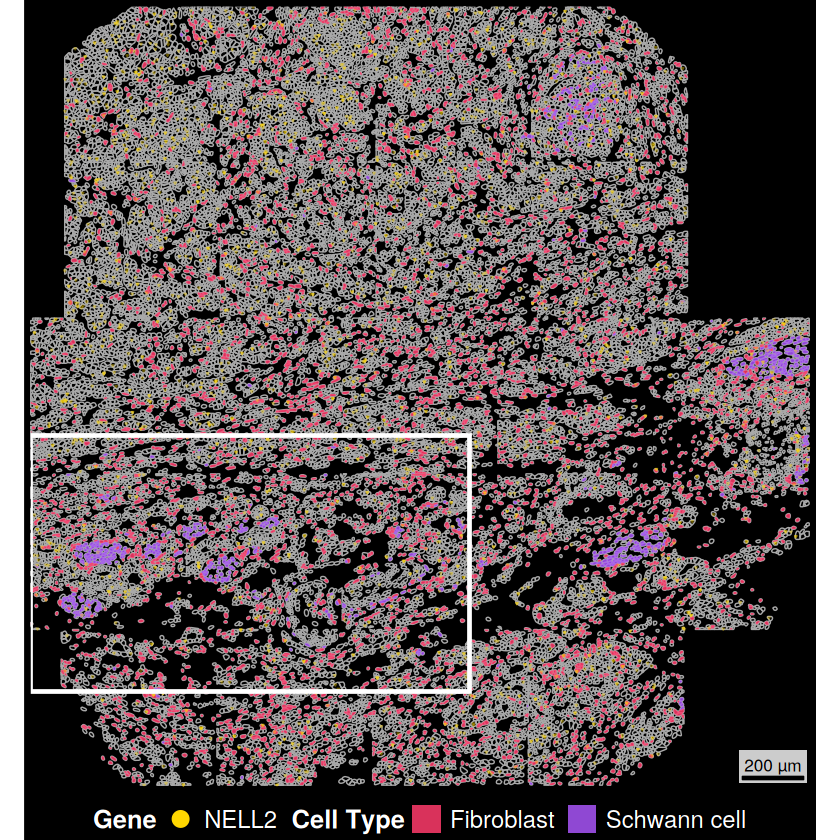

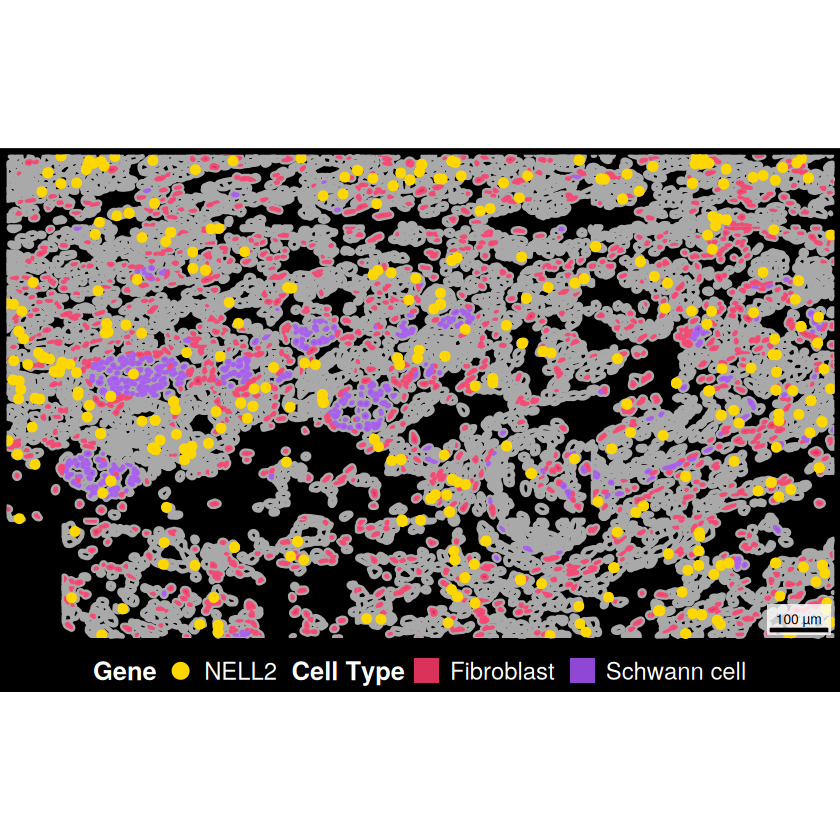

In [12]:
## ── 调用 ──────────────────────────────────────────
result <- plotCosMxGenesWithCelltype(
  polygons               = polygons1,
  tx                     = tx1,
  genes                  = c("NELL2"),
  gene_colors            = gene_colors,
  cell_meta              = cell_meta1,
  celltypes              = names(celltype_colors),
  celltype_colors        = celltype_colors,
  celltype_alpha         = 0.85,
  point_shape_full       = 25, ## 46是像素点，19是圆
  point_alpha_full       = 0.4,
  point_size_full        = 0.1,
  zoom.x                 = 0,
  zoom.y                 = 0.12,
  zoom.width.x           = 12000,
  zoom.width.y           = 7000,
  scale_length_um_full   = 200,
  scale_length_um_zoom   = 100,
  label_size_full        = 10,
  label_size_zoom        = 8,
  zoom.rect.color        = "white",
  zoom.rect.linetype     = "solid",
  legend_text_size       = 14
)

## 原图（底部图例）
result$full
result$zoom



In [13]:
## 选择样本和视野
sample = "2506712"
spatial_1 = c(0, 11118000)
spatial_2 = c(0, 1151111100)

reduction = seu_list[[sample]]@reductions$spatial@cell.embeddings
s1_col = reduction[, "spatial_1", drop = TRUE]
s2_col = reduction[, "spatial_2", drop = TRUE]
keep = spatial_1[1] < s1_col & s1_col < spatial_1[2] &
       spatial_2[1] < s2_col & s2_col < spatial_2[2]
cell_id = rownames(reduction)[keep]
cells = seu_list[[sample]]@meta.data[cell_id, ]$cell

tx1 = filter(tx, cell %in% cells)
polygons1 = filter(polygons, cell %in% cells)
cell_meta1 <- seu_list[[sample]]@meta.data

In [14]:
## ── 配色方案推荐（黑色背景 + 2基因 + 2细胞类型） ─────────────────────────
gene_colors <- c(
  "NELL2" = "#FFD700"  # 金黄
)

celltype_colors <- c(
  "Fibroblast"           = "#FF3B6B",   # 玫红（比 #FF6B6B 更饱和、斑块更显眼）
  "Schwann cell" = "#A855F7"   
)


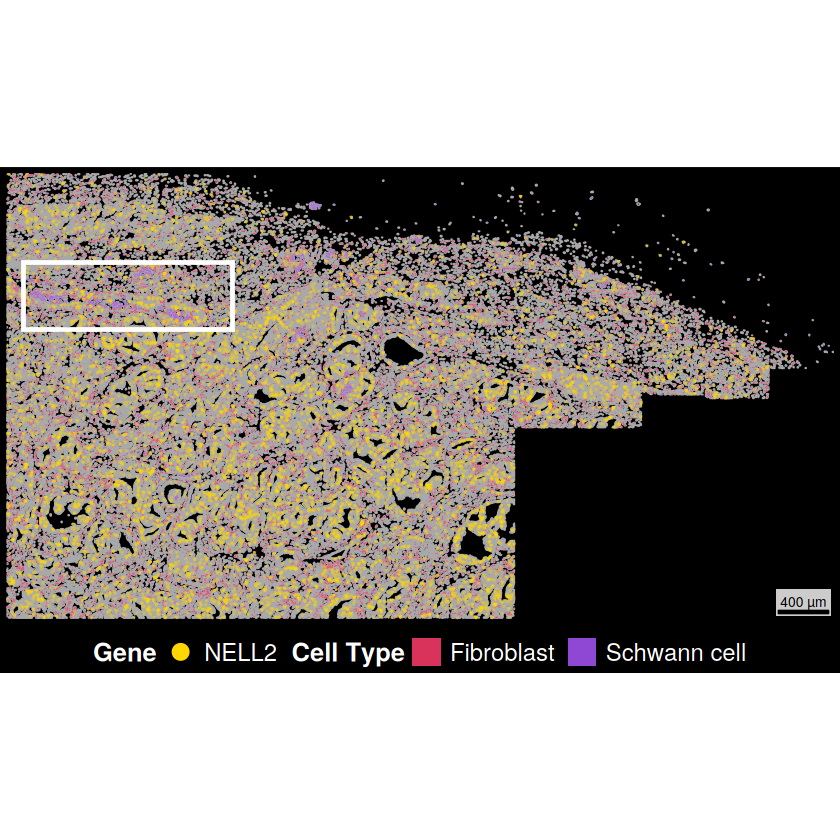

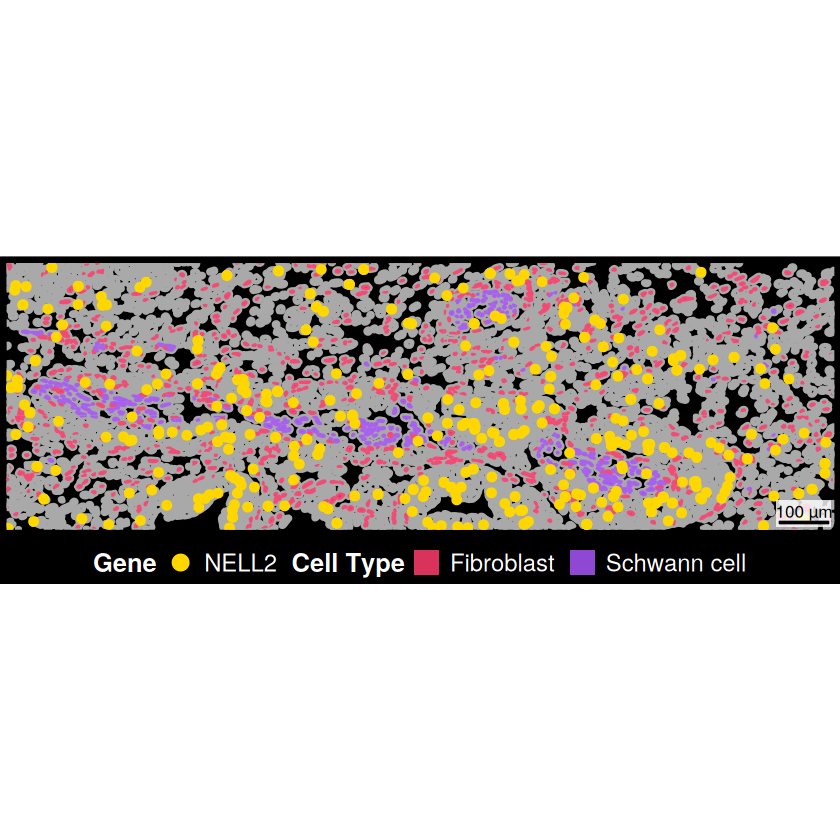

In [15]:
## ── 调用 ──────────────────────────────────────────
result <- plotCosMxGenesWithCelltype(
  polygons               = polygons1,
  tx                     = tx1,
  genes                  = c("NELL2"),
  gene_colors            = gene_colors,
  cell_meta              = cell_meta1,
  celltypes              = names(celltype_colors),
  celltype_colors        = celltype_colors,
  celltype_alpha         = 0.85,
  point_shape_full       = 25, ## 46是像素点，19是圆
  point_alpha_full       = 0.4,
  point_size_full        = 0.1,
  zoom.x                 = 0.02,
  zoom.y                 = 0.65,
  zoom.width.x           = 14000,
  zoom.width.y           = 4500,
  scale_length_um_full   = 400,
  scale_length_um_zoom   = 100,
  label_size_full        = 8,
  label_size_zoom        = 10,
  zoom.rect.color        = "white",
  zoom.rect.linetype     = "solid",
  legend_text_size       = 14
)

## 原图（底部图例）
result$full
result$zoom

